Name: **Stephane Chambrelain Talla Fotsing**  
Student Number: **ST139766**  
Program: **Data Analytics and Artificial Intelligence**  
Course - **Introduction to Artificial Intelligence**  
**Assignment 14: Ethical AI Analysis and Explainability**

In [10]:
%pip install -q fairlearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.5/135.5 kB 5.0 MB/s eta 0:00:00


In [16]:
%pip install -q shap lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 18.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [20]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
    )
import matplotlib.pyplot as plt
from fairlearn.metrics import (
    MetricFrame, selection_rate, false_positive_rate, true_positive_rate
    )
import shap
from lime.lime_tabular import LimeTabularExplainer

## 1. Dataset Preparation

In [2]:
# Load the dataset
columns = [
    "age", "workclass", "fnlwgt", "education", "education_num",
    "marital_status", "occupation", "relationship", "race",
    "sex", "capital_gain", "capital_loss", "hours_per_week",
    "native_country", "income"
]
# Dataset from the UCI Machine Learning Repository
url = ("https://archive.ics.uci.edu/ml/" "machine-learning-databases/adult/adult.data")

df = pd.read_csv(url, names=columns, skipinitialspace=True, na_values="?")
# Display the shape and the head of the dataset
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (32561, 15)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [3]:
# Select and preprocess the features
features = ["age", "education_num", "capital_gain", "capital_loss", "hours_per_week"]

# Keep the columns needed for modelling and fairness analysis
data = df[features + ["income", "sex"]].copy()

# Remove rows missing any required values
data = data.dropna().reset_index(drop=True)

X = data[features].copy()

# Target: 0 = income <=50K, 1 = income >50K
y = data["income"].map({"<=50K": 0, ">50K": 1})

print("Features shape:", X.shape)
print("\nTarget counts:")
print(y.value_counts())

Features shape: (32561, 5)

Target counts:
income
0    24720
1     7841
Name: count, dtype: int64


In [4]:
# Identify the sensitive attribute
sensitive_attribute = data["sex"].copy()
print("Sensitive attribute: sex")
print(sensitive_attribute.value_counts())

Sensitive attribute: sex
sex
Male      21790
Female    10771
Name: count, dtype: int64


## 2. Model Training and Evaluation

In [6]:
# Split the dataset
X_train, X_test, y_train, y_test, sensitive_train, sensitive_test = (
    train_test_split(X, y, sensitive_attribute, test_size=0.20, random_state=42,stratify=y)
)
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 26048
Testing samples: 6513


In [7]:
# Train logistic regression
model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=42))
model.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregression',
                 LogisticRegression(max_iter=1000, random_state=42))])

In [8]:
# Make predictions and evaluate performance
y_pred = model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test, y_pred, labels=[0, 1], target_names=["Income <=50K", "Income >50K"], digits=4, zero_division=0)
)

Accuracy: 0.8174

Classification Report:
              precision    recall  f1-score   support

Income <=50K     0.8348    0.9470    0.8874      4945
 Income >50K     0.7099    0.4088    0.5188      1568

    accuracy                         0.8174      6513
   macro avg     0.7723    0.6779    0.7031      6513
weighted avg     0.8047    0.8174    0.7986      6513



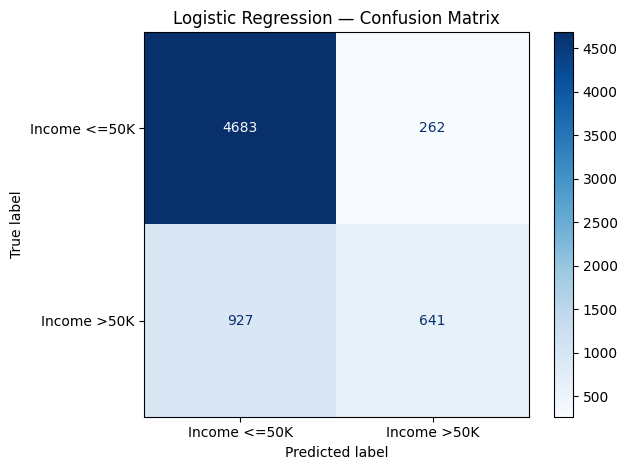

In [9]:
# Visualize the confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Income <=50K", "Income >50K"])

cm_display.plot(cmap="Blues", values_format="d")
plt.title("Logistic Regression — Confusion Matrix")
plt.tight_layout()
plt.show()

## 3. Fairness Analysis

In [13]:
# Create a MetricFrame
metrics = {
    "Selection rate": selection_rate,
    "False positive rate": false_positive_rate,
    "True positive rate": true_positive_rate
}
metric_frame = MetricFrame(metrics=metrics, y_true=y_test, y_pred=y_pred, sensitive_features=sensitive_test)

print(metric_frame.by_group.round(4))

        Selection rate  False positive rate  True positive rate
sex                                                            
Female          0.0857               0.0429              0.4204
Male            0.1649               0.0594              0.4067


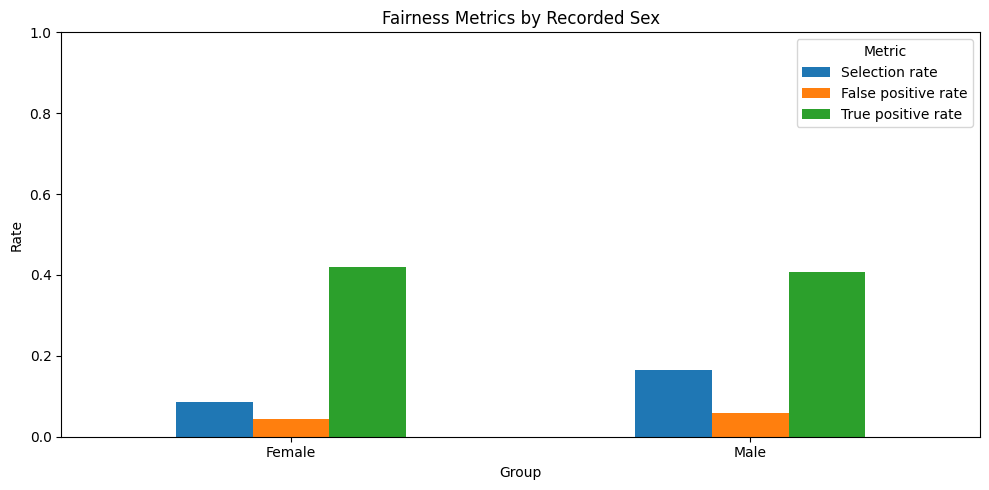

In [14]:
# Visualize the metrics
metric_frame.by_group.plot(kind="bar", figsize=(10, 5), rot=0)
# Ttile, label & legend
plt.title("Fairness Metrics by Recorded Sex")
plt.xlabel("Group")
plt.ylabel("Rate")
plt.ylim(0, 1)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

In [15]:
# Display the differences between groups
print("Absolute gaps between groups:")
print(metric_frame.difference().round(4))

Absolute gaps between groups:
Selection rate         0.0791
False positive rate    0.0165
True positive rate     0.0138
dtype: float64


## 4. Explainability Analysis

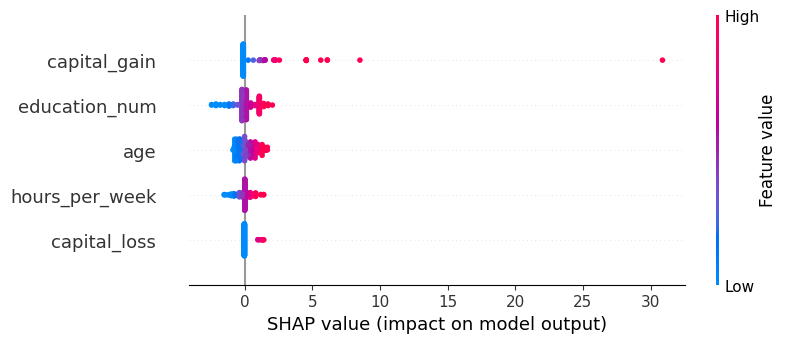

In [22]:
# Calculate SHAP values
scaler = model.named_steps["standardscaler"]
classifier = model.named_steps["logisticregression"]

# Use small samples to keep the explanation fast
background = X_train.sample(n=100, random_state=42)
X_explain = X_test.sample(n=200, random_state=42)

background_scaled = scaler.transform(background)
X_explain_scaled = scaler.transform(X_explain)

explainer = shap.LinearExplainer(classifier, background_scaled, feature_names=X_train.columns.tolist())
shap_values = explainer(X_explain_scaled)

# Display original feature values in the plots
shap_values.data = X_explain.to_numpy()

# SHAP summary plot
shap.plots.beeswarm(shap_values, max_display=5)

Predicted class: 0
Probability of income >50K: 0.3155


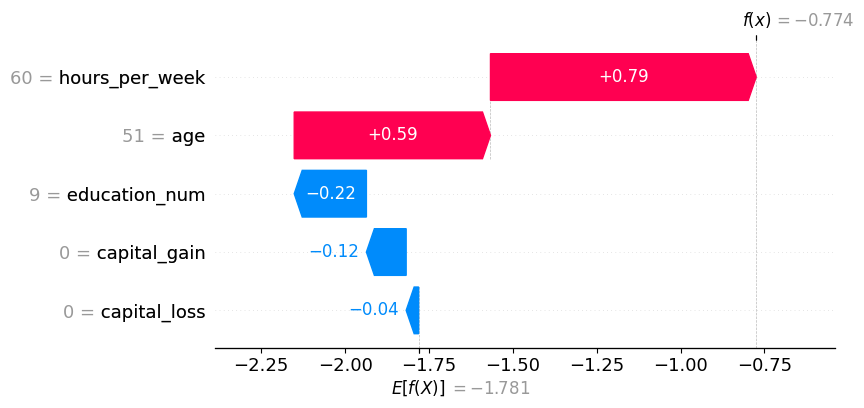

In [23]:
# SHAP waterfall plot
person = X_explain.iloc[[0]]

print("Predicted class:", model.predict(person)[0])
print("Probability of income >50K:", round(model.predict_proba(person)[0, 1], 4))

shap.plots.waterfall(shap_values[0], max_display=5)

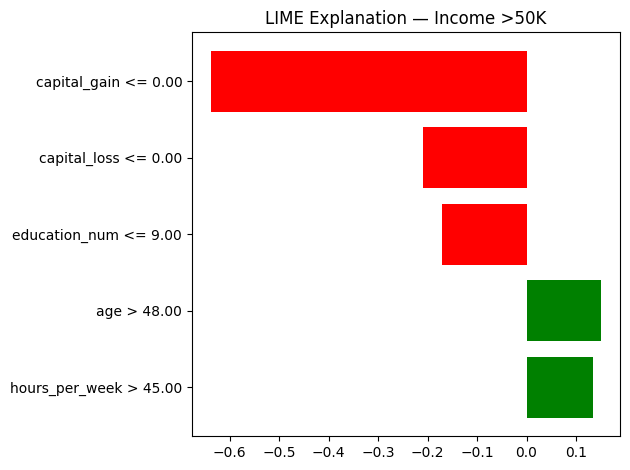

In [24]:
# Local explanation using LIME
lime_explainer = LimeTabularExplainer(
    training_data=X_train.to_numpy(), feature_names=X_train.columns.tolist(),
    class_names=["Income <=50K", "Income >50K"], mode="classification", random_state=42
)

# Keep column names and apply the full model pipeline
def predict_probabilities(values):
    frame = pd.DataFrame(values, columns=X_train.columns)
    return model.predict_proba(frame)

lime_explanation = lime_explainer.explain_instance(
    data_row=person.iloc[0].to_numpy(), predict_fn=predict_probabilities,
    labels=(1,), num_features=5, num_samples=1000
)
# Title & display
lime_explanation.as_pyplot_figure(label=1)
plt.title("LIME Explanation — Income >50K")
plt.tight_layout()
plt.show()

In [25]:
!find "/content/drive/MyDrive/Colab Notebooks" -iname "Assignment_14.ipynb"

find: ‘/content/drive/MyDrive/Colab Notebooks’: No such file or directory


In [26]:
!ls -la /content/drive

ls: cannot access '/content/drive': No such file or directory


In [27]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [28]:
!ls -la /content/drive

total 24
drwx------ 5 root root 4096 Sep 19 08:50 .
drwxr-xr-x 1 root root 4096 Sep 19 08:50 ..
dr-x------ 4 root root 4096 Sep 19 08:50 .Encrypted
drwx------ 2 root root 4096 Sep 19 08:50 MyDrive
dr-x------ 2 root root 4096 Sep 19 08:50 .shortcut-targets-by-id
drwx------ 5 root root 4096 Sep 19 08:50 .Trash-0


In [29]:
!find "/content/drive/MyDrive" -iname "Assignment_14.ipynb"

/content/drive/MyDrive/Colab Notebooks/Assignment_14.ipynb


In [30]:
!ls -la /content/colab-git-assignment2-ST

ls: cannot access '/content/colab-git-assignment2-ST': No such file or directory


In [31]:
!git clone https://github.com/StephaneTF/colab-git-assignment2-ST.git /content/colab-git-assignment2-ST

Cloning into '/content/colab-git-assignment2-ST'...
remote: Enumerating objects: 66, done.
remote: Counting objects: 100% (66/66), done.
remote: Compressing objects: 100% (54/54), done.
remote: Total 66 (delta 25), reused 28 (delta 6), pack-reused 0 (from 0)
Receiving objects: 100% (66/66), 3.08 MiB | 9.31 MiB/s, done.
Resolving deltas: 100% (25/25), done.


In [32]:
!ls -la /content/colab-git-assignment2-ST

total 3784
drwxr-xr-x 6 root root    4096 Sep 19 08:52  .
drwxr-xr-x 1 root root    4096 Sep 19 08:52  ..
-rw-r--r-- 1 root root  490404 Sep 19 08:52  Assignment_15.ipynb
-rw-r--r-- 1 root root    5415 Sep 19 08:52  assignment2.ipynb
drwxr-xr-x 2 root root    4096 Sep 19 08:52  Assignment_8
drwxr-xr-x 2 root root    4096 Sep 19 08:52  Assignment_9
drwxr-xr-x 8 root root    4096 Sep 19 08:52  .git
drwxr-xr-x 2 root root    4096 Sep 19 08:52  Lesson_10_assignment
-rw-r--r-- 1 root root   12704 Sep 19 08:52  Lesson_3_assignment.ipynb
-rw-r--r-- 1 root root   80271 Sep 19 08:52 'Lesson 4 assignment.ipynb'
-rw-r--r-- 1 root root  549515 Sep 19 08:52  Lesson_5_Assignment.ipynb
-rw-r--r-- 1 root root 2321005 Sep 19 08:52  Lesson_6_ml_basic_assignment.ipynb
-rw-r--r-- 1 root root  376413 Sep 19 08:52  Lesson_7_assignment.ipynb
